# MoE Dual-Branch Encoder — UMAP + KMeans Visualizer

Follows the same 3-panel layout for each head:
- **Panel 1** — coloured by Subject ID
- **Panel 2** — coloured by KMeans cluster (with ARI / NMI / Silhouette)
- **Panel 3** — coloured by Stress label

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import umap
from torch.utils.data import DataLoader, Subset
import pickle
from models.net.moe_encoder import MoEDualBranchEncoder
REPO_ROOT = "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from sklearn.manifold import TSNE

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print("Imports OK")

: 

## 1. Configuration  ← edit here

In [ ]:
# ── Checkpoint ────────────────────────────────────────────────────────────────
CHECKPOINT = ""

# ── Dataset ───────────────────────────────────────────────────────────────────
DATASET_NAME = "WESADDataset"      # WESADDataset | SWELLDataset | StressIDDataset
DATASET_PATH = "/home/s223149341/SSL-invariance-Subject_Project_model/data/WESAD/wesad_10_05_no_standardize"

ALL_DEFAULTS = {
    "WESADModel": {
        "model_path": "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/dual_branch_no_scale/moe_dual_branch_WESADDataset_0/pretrain/encoder_best_.pt",
        "dataset_name": "WESADDataset",
        "dataset_path": "/home/s223149341/SSL-invariance-Subject_Project_model/data/WESAD/wesad_10_05_no_standardize",
    },
    "SWELLModel": {
        "model_path": "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/dual_branch_no_scale/moe_dual_branch_SWELLDataset_0/pretrain/encoder_best_.pt",
        "dataset_name": "SWELLDataset",
        "dataset_path": "/home/s223149341/SSL-invariance-Subject_Project_model/data/SWELL/SWELL_1280_320_3label",
    },
}


# ── Encoder architecture (must match the checkpoint) ─────────────────────────
INPUT_DIM         = 1280
OUTPUT_DIM        = 64
PROJECTION_OUTPUT = 32
KERNEL_SIZE       = 10
STRIDE            = 1
DROPOUT_PROB      = 0.1

# ── UMAP ──────────────────────────────────────────────────────────────────────
N_NEIGHBORS  = 15
MIN_DIST     = 0.1
RANDOM_STATE = 42

# ── KMeans ────────────────────────────────────────────────────────────────────
# Set to None to auto-set k = number of unique subjects
KMEANS_K = None

# ── Misc ──────────────────────────────────────────────────────────────────────
BATCH_SIZE = 256
OUTPUT_DIR = "./umap_plots"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

: 

In [3]:
from datasets.wesad_dataset import WESADDataset
from datasets.swell_stressid_dataset import SWELL_STRESSID_Dataset

#Get the dataset from the config file
def get_wesad_dataset(config):
    dat_cfg = config['pretrain_args']['dataset_args']['train_dataset_args']
    dat_cfg.pop('data_name', None)
    dat_cfg["dataset_path"] = "/home/s223149341/SSL-invariance-Subject_Project_model/data/WESAD/wesad_10_05_no_standardize"
    print("Dataset config:", dat_cfg)
    dataset =  WESADDataset(**dat_cfg)
    return dataset
    

In [4]:
import json

path = "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/configs/pretrain_dual_branch/no_scale/pretrain_wesad.json"
with open(path) as f:
    cfg = json.load(f)


In [5]:
samples = get_wesad_dataset(cfg)

Dataset config: {'dataset_path': '/home/s223149341/SSL-invariance-Subject_Project_model/data/WESAD/wesad_10_05_no_standardize', 'include_labels': 'true', 'split': None, 'sub_sample_frac': 1.0, 'data_views': {'x1': {'apply_transform': True}, 'x2': {'apply_transform': True}}, 'transform_dict_core': {'ConstantAmplitudeScalingStochastic': {'scale_min': 0.25, 'scale_max': 2.0}, 'GaussianNoiseStochastic': {'sigma_scale_min': 0.0, 'sigma_scale_max': 0.5}, 'TimeWarpingStochastic': {'sigma_min': 0.01, 'sigma_max': 0.5, 'knot_min': 1, 'knot_max': 4}, 'TimeShiftStochastic': {'shift_len_min': 120, 'shift_len_max': 240}, 'PermuteStochastic': {'n_splits_max': 4}}, 'transform_dict_artifact': {'Identity': {}, 'JumpArtifactStochastic': {'shift_factor_min': 0.01, 'shift_factor_max': 0.1}, 'LooseSensorArtifactStochastic': {'width_min': 10, 'width_max': 30}, 'HighFrequencyNoiseStochastic': {'sigma_scale_min': 0.1, 'sigma_scale_max': 1.0}, 'Flip': {}, 'AmplitudeWarpingStochastic': {'sigma_min': 0.01, 'sigm

100%|██████████| 15/15 [00:04<00:00,  3.73it/s]


sub sample frac is 1.0
Sampled 65428 examples
Label 0 count: 45791 = 69.98685578039984%
Label 1 count: 19637 = 30.01314421960017%


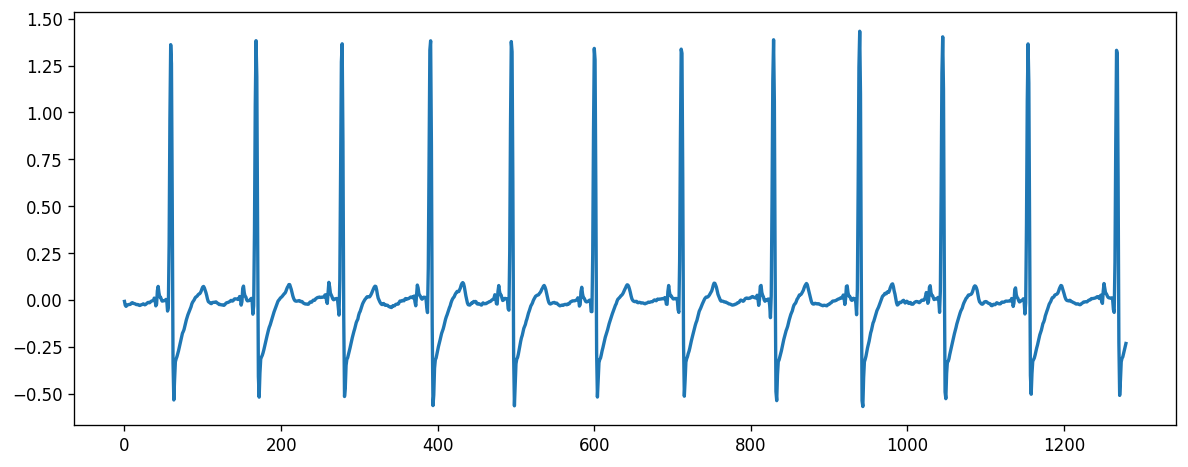

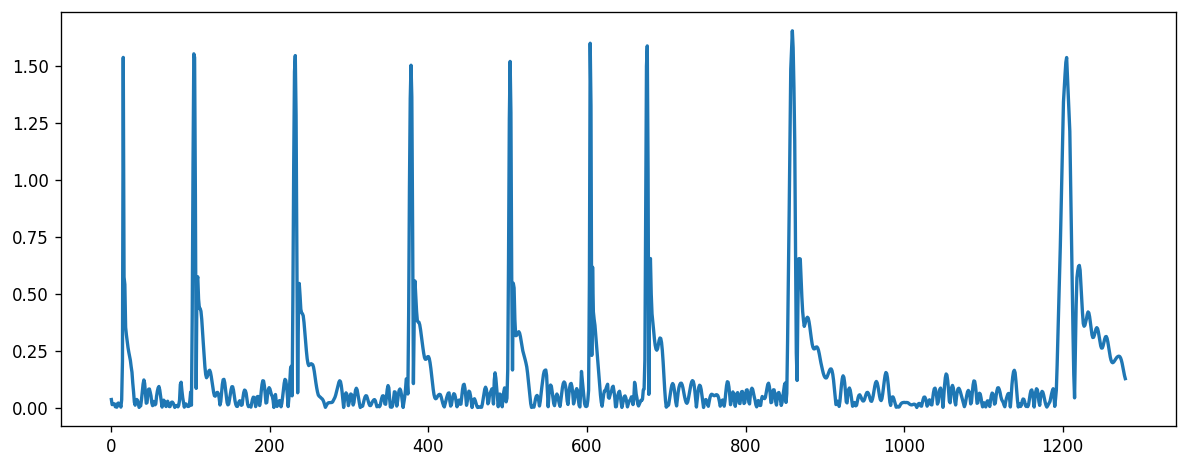

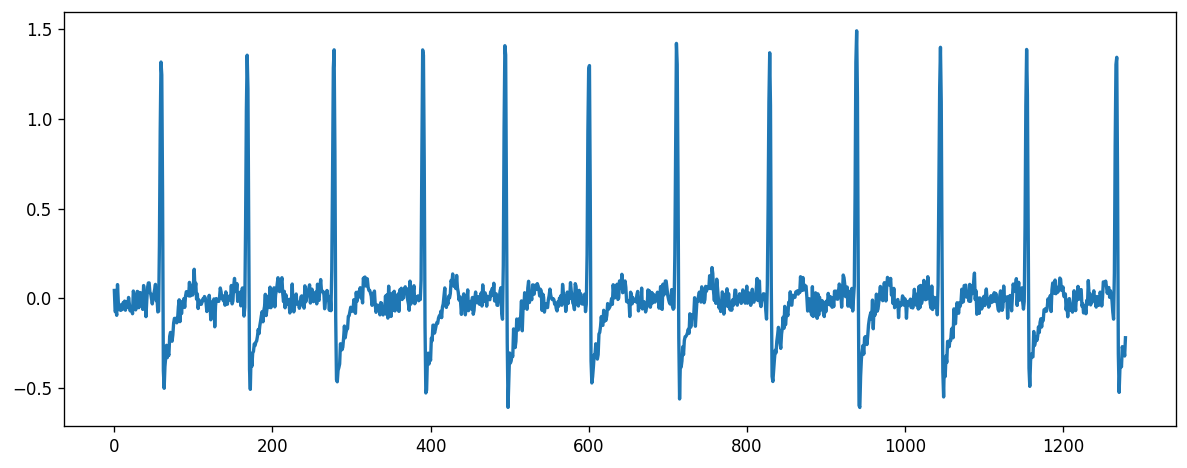

In [12]:
import matplotlib.pyplot as plt

x = samples[0]['x']
x1 = samples[0]['x1']['x']
x2 = samples[0]['x2']['x']

# --- ECG x ---
plt.figure(figsize=(10, 4))
plt.plot(x, linewidth=2)
plt.tight_layout()
plt.show()


# --- ECG x1 ---
plt.figure(figsize=(10, 4))
plt.plot(x1, linewidth=2)
plt.tight_layout()
plt.show()


# --- ECG x2 ---
plt.figure(figsize=(10, 4))
plt.plot(x2, linewidth=2)
plt.tight_layout()
plt.show()

# 2 Metrics Computation

In [18]:
# Uniformity
def calculate_uniformity(embeddings, temperature=2.0):
    # Normalize embeddings
    norm_embeddings = F.normalize(embeddings, dim=1)
    # Compute pairwise distances
    sq_pdist = torch.pdist(norm_embeddings, p=2).pow(2)
    return sq_pdist.mul(-temperature).exp().mean().log()

# Alignment
def calculate_alignment(first_emebedding, second_embeddings, alpha=2.0):
    return (first_emebedding - second_embeddings).norm(dim=1).pow(alpha).mean()


def calculate_label_separability(embeddings, labels):
    norm_embedding = F.normalize(embeddings, dim=1)
    distance = torch.cdist(norm_embedding, norm_embedding, p=2)  # NxN
    same_label_mask = labels.unsqueeze(1) == labels.unsqueeze(0)
    different_label_mask = ~same_label_mask

    # avoid self-comparison (diagonal)
    eye = torch.eye(labels.size(0), dtype=torch.bool, device=labels.device)
    same_label_mask = same_label_mask & ~eye

    same_dist = distance[same_label_mask]
    different_dist = distance[different_label_mask]

    score = same_dist.mean() / (different_dist.mean() + 1e-8)
    return score.item()


# Subject Separability
def calculate_subject_separability(embeddings, subjects):
    norm_embedding = F.normalize(embeddings, dim=1)

    distance = torch.cdist(norm_embedding, norm_embedding, p=2)

    same_subject_mask = subjects.unsqueeze(1) == subjects.unsqueeze(0)
    different_subject_mask = ~same_subject_mask

    eye = torch.eye(subjects.size(0), dtype=torch.bool, device=subjects.device)
    same_subject_mask = same_subject_mask & ~eye

    same_dist = distance[same_subject_mask]
    different_dist = distance[different_subject_mask]

    score = same_dist.mean() / (different_dist.mean() + 1e-8)
    return score.item()



## 2. Helper Functions

In [4]:
def cmap_colors(ids, cmap_name="tab20"):
    """Assign one colour per unique id.  Returns colours array, unique ids, cmap."""
    unique       = np.unique(ids)
    cmap         = cm.get_cmap(cmap_name, len(unique))
    id_to_color  = {uid: cmap(i) for i, uid in enumerate(unique)}
    return np.array([id_to_color[i] for i in ids]), unique, cmap

## 3. Load Encoder

In [5]:

def create_encoder_from_checkpoint(checkpoint_path):
    device  = torch.device(DEVICE)
    encoder = MoEDualBranchEncoder(
        input_dim         = INPUT_DIM,
        dropout_prob      = DROPOUT_PROB,
        kernel_size       = KERNEL_SIZE,
        stride            = STRIDE,
        output_dim        = OUTPUT_DIM,
        projection_output = PROJECTION_OUTPUT,
    ).to(device)

    ckpt   = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    sd     = ckpt.get("state_dict", ckpt)
    enc_sd = {}
    for k, v in sd.items():
        k = k.replace("module.", "", 1)
        for prefix in ("encoder_q.", "encoder.", "encoder_i."):
            if k.startswith(prefix):
                k = k[len(prefix):]
                break
        enc_sd[k] = v

    msg = encoder.load_state_dict(enc_sd, strict=False)
    if msg.missing_keys:
        print("Missing keys:", msg.missing_keys)
    encoder.eval()
    print("Encoder loaded OK")
    return encoder

In [6]:
for dataset in ALL_DEFAULTS:
    ckpt = ALL_DEFAULTS[dataset]["model_path"]
    ALL_DEFAULTS[dataset]["encoder"] = create_encoder_from_checkpoint(ckpt)

Encoder loaded OK
Encoder loaded OK


## 4. Build DataLoader

In [7]:
from datasets.wesad_dataset import WESADDataset
from datasets.swell_stressid_dataset import SWELL_STRESSID_Dataset

def create_dataloader(data_path):
    ds_args = dict(
        dataset_path              = data_path,
        include_labels            = True,
        sub_sample_frac           = None,
        data_views                = None,
        transform_dict_core       = None,
        transform_dict_artifact   = None,
        transform_global_core     = None,
        transform_global_artifact = None,
    )

    if   DATASET_NAME == "WESADDataset":                    ds = WESADDataset(**ds_args)
    elif DATASET_NAME in ("SWELLDataset","StressIDDataset"): ds = SWELL_STRESSID_Dataset(**ds_args)
    else: raise ValueError(DATASET_NAME)

    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, drop_last=False)
    print(f"Dataset size: {len(ds)}  |  Batches: {len(loader)}")
    return loader


for dataset in ALL_DEFAULTS:
    data_path = ALL_DEFAULTS[dataset]["dataset_path"]
    ALL_DEFAULTS[dataset]["dataloader"] = create_dataloader(data_path)

100%|██████████| 15/15 [00:06<00:00,  2.41it/s]


sub sample frac is None
Sampled 65428 examples
Label 0 count: 45791 = 69.98685578039984%
Label 1 count: 19637 = 30.01314421960017%
Dataset size: 65428  |  Batches: 256


100%|██████████| 25/25 [00:07<00:00,  3.23it/s]


sub sample frac is None
Sampled 51714 examples
Label 0 count: 33487 = 64.75422516146499%
Label 1 count: 18227 = 35.24577483853502%
Dataset size: 51714  |  Batches: 203


## 5. Extract Embeddings

In [8]:
def create_embeddings(encoder, loader):
    z_inv_list, z_spec_list, h_out_list = [], [], []
    subj_list, label_list = [], []

    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE).float()
            h_out, z_inv, z_spec = encoder(x)

            z_inv_list.append(z_inv.cpu().numpy())
            z_spec_list.append(z_spec.cpu().numpy())
            h_out_list.append(h_out.cpu().numpy())

            subj = batch.get("subject_id_int", None)
            subj_list.append(subj.cpu().numpy())

            lbl = batch.get("y", None)
            label_list.append(lbl.cpu().numpy().flatten().astype(int))

    Z_INV  = np.vstack(z_inv_list)
    Z_SPEC = np.vstack(z_spec_list)
    H_OUT  = np.vstack(h_out_list)
    SUBJ   = np.concatenate(subj_list)
    LABELS = np.concatenate(label_list)

    print(f"z_inv  : {Z_INV.shape}")
    print(f"z_spec : {Z_SPEC.shape}")
    print(f"h_out  : {H_OUT.shape}")
    print(f"Subjects : {np.unique(SUBJ)}")
    print(f"Labels   : {np.unique(LABELS)}")

    return {"Z_INV": Z_INV, "Z_SPEC": Z_SPEC, "H_OUT": H_OUT, "SUBJ": SUBJ, "LABELS": LABELS}


In [9]:
for dataset in ALL_DEFAULTS:
    encoder = ALL_DEFAULTS[dataset]["encoder"]
    loader  = ALL_DEFAULTS[dataset]["dataloader"]
    ALL_DEFAULTS[dataset].update(create_embeddings(encoder, loader))

z_inv  : (65428, 32)
z_spec : (65428, 32)
h_out  : (65428, 64)
Subjects : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Labels   : [0 1]
z_inv  : (51714, 32)
z_spec : (51714, 32)
h_out  : (51714, 64)
Subjects : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Labels   : [0 1]


## 6. UMAP + TSNE for Each Head

In [21]:
run_data = {}

def compute_metrics(embeddings, subjects, labels):
    embeddings = torch.from_numpy(embeddings).float()
    subjects = torch.tensor(subjects)
    labels = torch.tensor(labels)

    uniformity = calculate_uniformity(embeddings).item()
    label_separability = calculate_label_separability(embeddings, labels)
    subject_separability = calculate_subject_separability(embeddings, subjects)

    return {
        "Uniformity": round(uniformity, 3),
        "Label_Separability": round(label_separability, 3),
        "Subject_Separability": round(subject_separability, 3),
    }


def prepare_data(dataset_data):
    results = {}

    for emb, label in [
        (dataset_data["Z_INV"],  "Invariant Head (z_inv)"),
        (dataset_data["Z_SPEC"], "Subject-Specific Head (z_spec)"),
        (dataset_data["H_OUT"],  "Concat Head (h_out)"),
    ]:
        print(f"\nProcessing: {label}")

        # ── UMAP ─────────────────────────────────────────────
        print("  Fitting UMAP …")
        XY_umap = umap.UMAP(
            n_neighbors=N_NEIGHBORS,
            min_dist=MIN_DIST,
            random_state=RANDOM_STATE,
            n_components=2,
        ).fit_transform(emb)

        print(XY_umap.shape)
        print(dataset_data["LABELS"].shape)
        metrics = compute_metrics(
            emb,
            dataset_data["SUBJ"],
            dataset_data["LABELS"]
        )

        print(
            f"  Uniformity={metrics['Uniformity']}  "
            f"Label Sep={metrics['Label_Separability']}  "
            f"Subject Sep={metrics['Subject_Separability']}"
        )

        results[label] = {
            "label": label,
            "UMAP": XY_umap,
            "S": dataset_data["SUBJ"],
            "L": dataset_data["LABELS"]
            if np.any(dataset_data["LABELS"] >= 0)
            else None,
            "metrics": metrics,
        }

    print("\nAll heads processed.")
    return results

In [22]:
for dataset in ALL_DEFAULTS:
    print(f"Processing dataset: {dataset}")
    umap_run = prepare_data(ALL_DEFAULTS[dataset])
    run_data[dataset] = umap_run

OUTPUT_FILE = os.path.join('./', "umap_tsne_results.pkl")
with open(OUTPUT_FILE, "wb") as f:
    pickle.dump(run_data, f)
print(f"Saved run_data → {OUTPUT_FILE}")

Processing dataset: WESADModel

Processing: Invariant Head (z_inv)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(65428, 2)
(65428,)
  Uniformity=-3.613  Label Sep=0.98  Subject Sep=0.82

Processing: Subject-Specific Head (z_spec)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(65428, 2)
(65428,)
  Uniformity=-2.185  Label Sep=0.995  Subject Sep=0.045

Processing: Concat Head (h_out)
  Fitting UMAP …


...

(51714, 2)
(51714,)
  Uniformity=-0.689  Label Sep=0.97  Subject Sep=0.571

Processing: Subject-Specific Head (z_spec)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(51714, 2)
(51714,)
  Uniformity=-0.304  Label Sep=0.96  Subject Sep=0.499

Processing: Concat Head (h_out)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(51714, 2)
(51714,)
  Uniformity=-0.653  Label Sep=0.969  Subject Sep=0.565

All heads processed.
Saved run_data → ./umap_tsne_results.pkl


## 7. Plot — 3-Panel UMAP per Head

/tmp/ipykernel_1595483/276746573.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap         = cm.get_cmap(cmap_name, len(unique))


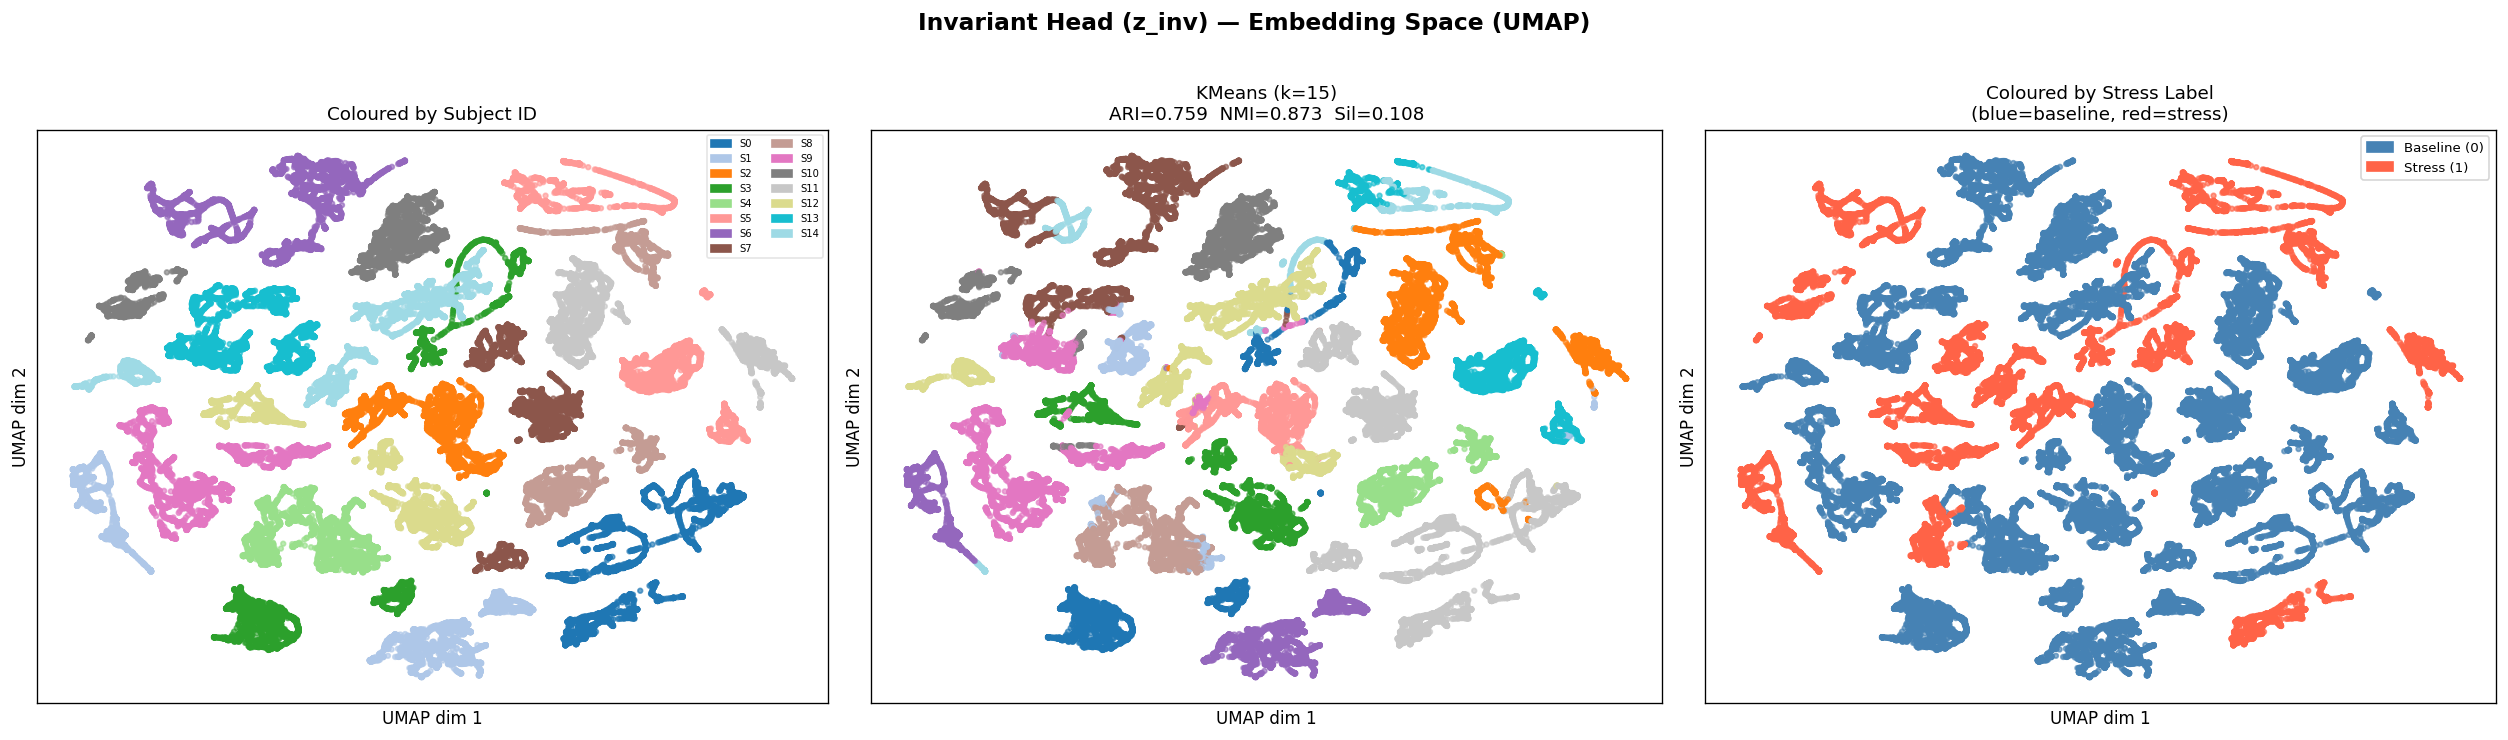

Saved → ./umap_plots/Invariant_Head_z_inv_umap.png


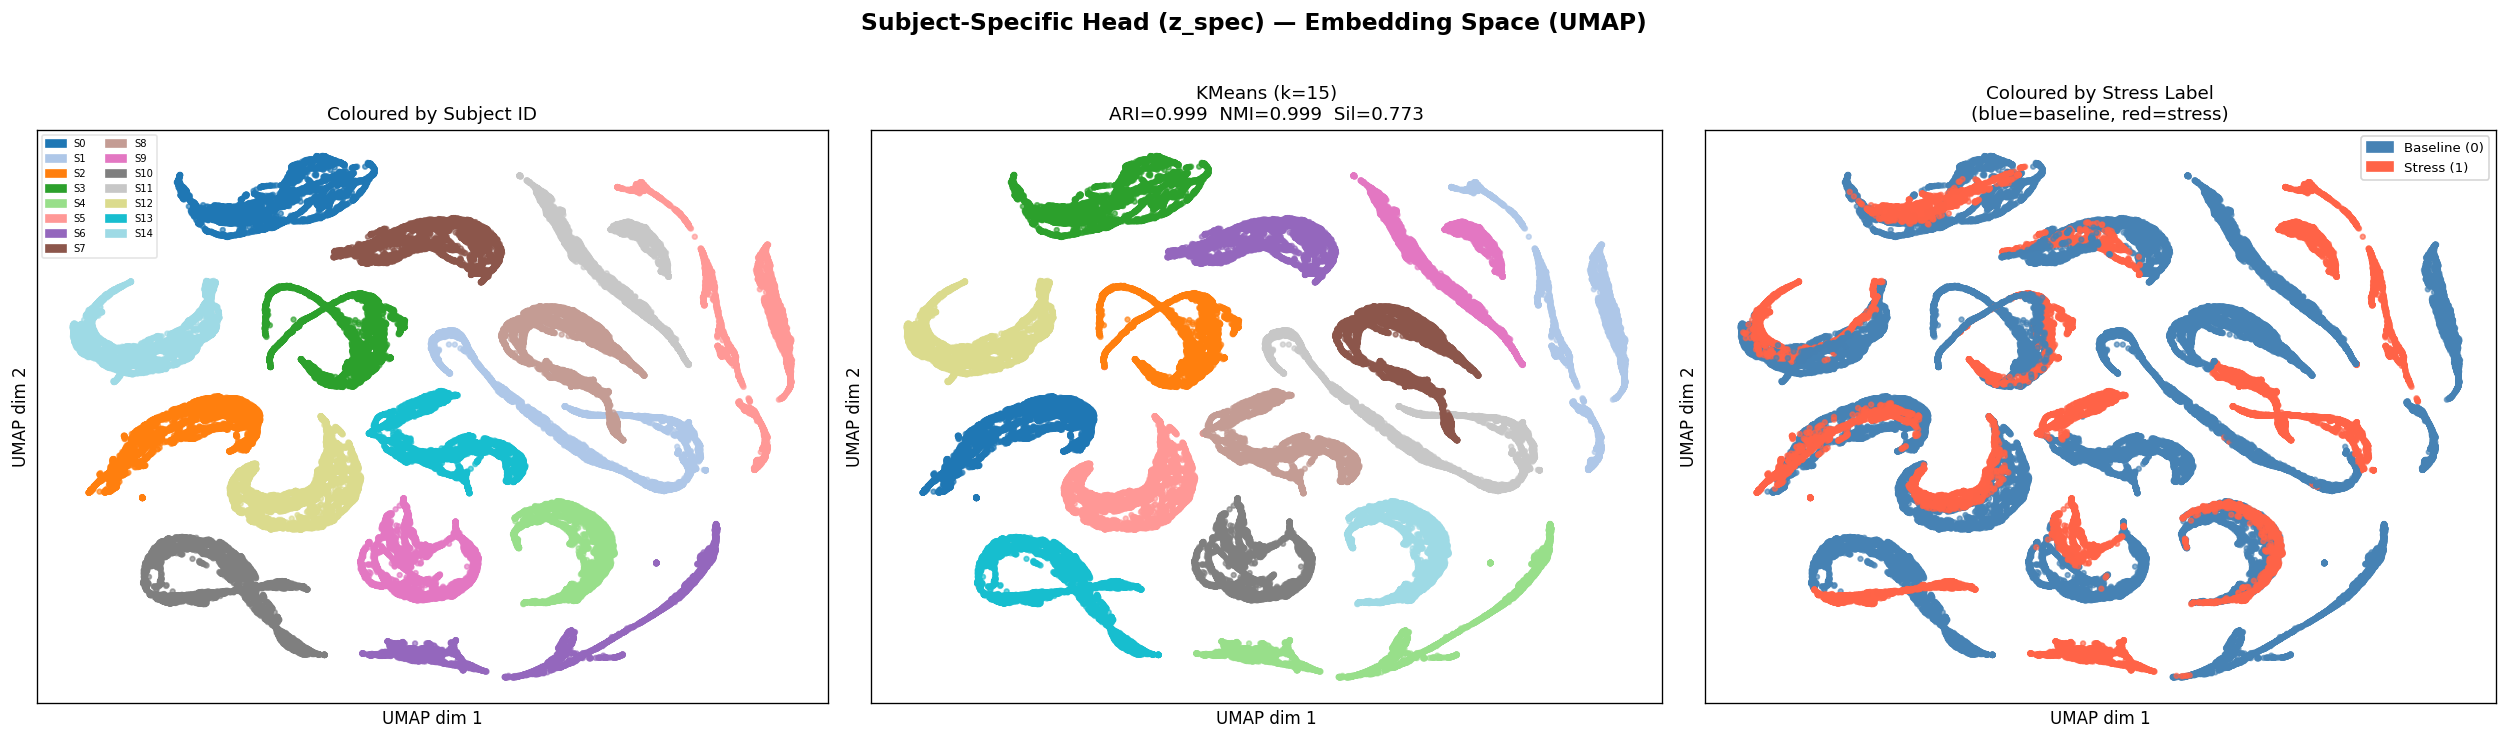

Saved → ./umap_plots/Subject-Specific_Head_z_spec_umap.png


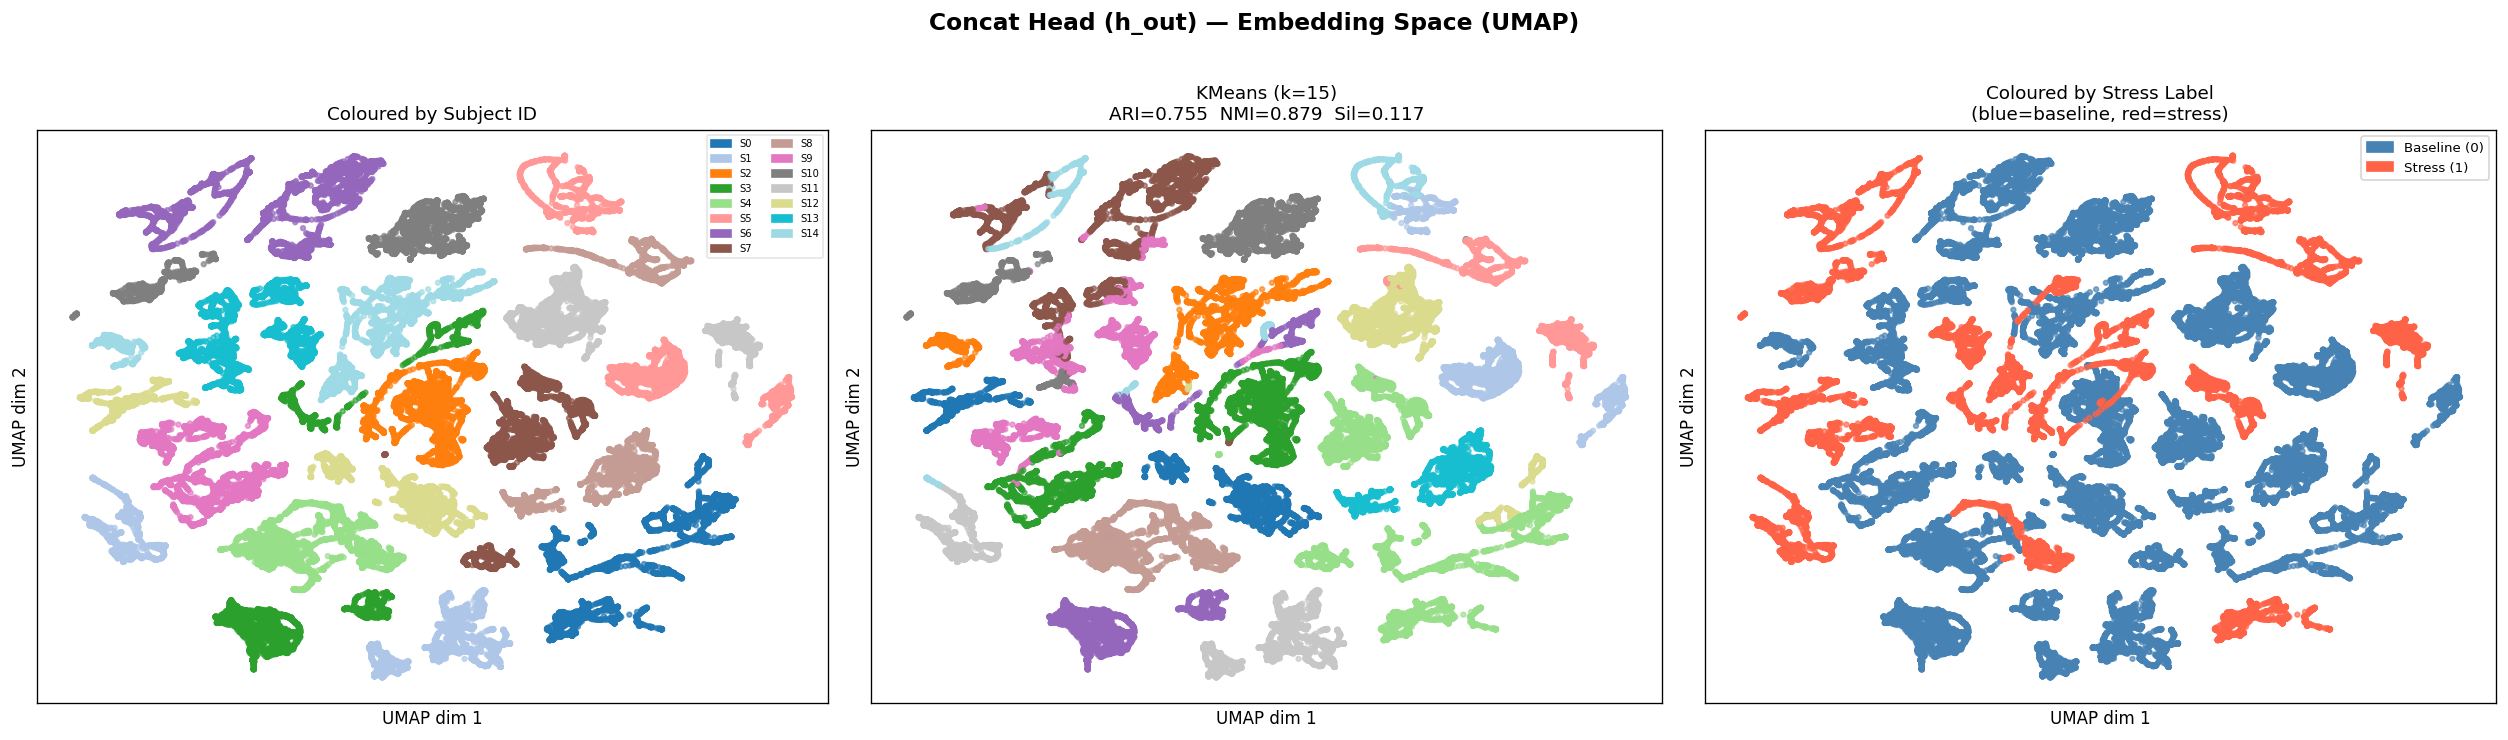

Saved → ./umap_plots/Concat_Head_h_out_umap.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import numpy as np

for dataset in run_data:
    rd = run_data[dataset]
    S, L, K = rd["S"], rd["L"], rd.get("K", None)
    m   = rd["metrics"]
    lbl = rd["label"]

    has_labels = L is not None

    for method in ["UMAP", "TSNE"]:
        XY = rd[method]
        ncols = 3 if has_labels else 2
        fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
        fig.suptitle(f"{lbl} — Embedding Space ({method})",
                     fontsize=14, fontweight="bold", y=1.02)

        # ── Panel 1: Subject ID ─────────────────────────────────────────────
        ax = axes[0]
        colors, unique_s, cmap_s = cmap_colors(S, "tab20")
        ax.scatter(XY[:, 0], XY[:, 1], c=colors, s=8, alpha=0.65)
        patches = [mpatches.Patch(color=cmap_s(i), label=f"S{uid}")
                   for i, uid in enumerate(unique_s)]
        ax.legend(handles=patches, fontsize=6, ncol=2,
                  loc="best", framealpha=0.5, markerscale=1.5)
        ax.set_title("Coloured by Subject ID", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(f"{method} dim 1"); ax.set_ylabel(f"{method} dim 2")

        # ── Panel 2: Stress label ───────────────────────────────────────────
        if has_labels:
            ax = axes[2]
            label_colors = np.where(L == 1, "tomato", "steelblue")
            ax.scatter(XY[:, 0], XY[:, 1], c=label_colors, s=8, alpha=0.65)
            ax.set_title("Coloured by Stress Label\n(blue=baseline, red=stress)",
                         fontsize=11)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlabel(f"{method} dim 1"); ax.set_ylabel(f"{method} dim 2")
            patches_l = [
                mpatches.Patch(color="steelblue", label="Baseline (0)"),
                mpatches.Patch(color="tomato",    label="Stress (1)"),
            ]
            ax.legend(handles=patches_l, fontsize=8, loc="best")

        plt.tight_layout()

        # ── Save Figure ────────────────────────────────────────────────────
        save_path = os.path.join(
            OUTPUT_DIR,
            f"{lbl.replace(' ', '_').replace('(','').replace(')','')}_{method.lower()}.png"
        )
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved → {save_path}")

## 8. Metrics Summary Table

In [ ]:
import pandas as pd

rows = []

for dataset in run_data:
    rd = run_data[dataset]
    m = rd["metrics"]
    lbl = rd["label"]

    # flatten metrics per dataset/run
    rows.append({
        "dataset": dataset,
        "label": lbl,
        "uniformity": m.get("uniformity"),
        "alignment": m.get("alignment"),
        "label_separability": m.get("label_separability"),
        "subject_separability": m.get("subject_separability"),
    })

df_metrics = pd.DataFrame(rows)

df_metrics

,ARI,NMI,Silhouette
Head,,,
Invariant Head (z_inv),0.759,0.873,0.108
Subject-Specific Head (z_spec),0.999,0.999,0.773
Concat Head (h_out),0.755,0.879,0.117


Saved → ./umap_plots/kmeans_metrics.csv
